In [ ]:
# FAZA 0 — Istraživanje redteam.txt (ground truth napada)
#
# Identifikujem entitete (korisnike i računare) koji učestvuju u napadima i
# analiziram raspored napada kroz 58 dana prikupljanja podataka.
# Rezultati direktno određuju obavezan sastav uzorka u Fazi 1 i
# granicu train/valid/test podele u Fazi 2.

# Radi se isključivo nad redteam.txt, auth.txt se u ovoj fazi ne učitava.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAW = Path(__file__).resolve().parent.parent / "data" / "raw"
REDTEAM = RAW / "redteam.txt"

SEC_PER_DAY = 86400  # rezolucija vremena je 1 sekunda; vreme kreće od 1

In [ ]:
# --- 1. Učitavanje redteam.txt ---
# Fajl je bez zaglavlja, kolone: time, user@domain, src_comp, dst_comp.
cols = ["time", "user", "src_comp", "dst_comp"]
rt = pd.read_csv(REDTEAM, header=None, names=cols)

print("Ukupno redteam događaja:", len(rt))
print("\nPrvih 5 redova:")
print(rt.head())

Ukupno redteam događaja: 749

Prvih 5 redova:
     time        user src_comp dst_comp
0  150885   U620@DOM1   C17693    C1003
1  151036   U748@DOM1   C17693     C305
2  151648   U748@DOM1   C17693     C728
3  151993  U6115@DOM1   C17693    C1173
4  153792   U636@DOM1   C17693     C294


In [ ]:
# --- 2. Izvedene kolone: dan i sat u danu ---
# Osnova za analizu vremenskog rasporeda napada u narednim koracima.
rt["day"] = (rt["time"] // SEC_PER_DAY) + 1  # dan 1..58
rt["hour_of_day"] = (rt["time"] % SEC_PER_DAY) // 3600  # sat u danu 0..23

print("Najraniji trenutak:", rt["time"].min(), "| dan:", int(rt["day"].min()))
print("Najkasniji trenutak:", rt["time"].max(), "| dan:", int(rt["day"].max()))
print("Raspon u danima:", int(rt["day"].min()), "-", int(rt["day"].max()))

Najraniji trenutak: 150885 | dan: 2
Najkasniji trenutak: 2557047 | dan: 30
Raspon u danima: 2 - 30


In [ ]:
# --- 3. Entiteti koji učestvuju u napadima ---
# Korisnici se obavezno uključuju u uzorak formiran u Fazi 1, jer predstavljaju
# jedine dostupne pozitivne primere za nadgledano učenje. Računari se ovde
# samo dokumentuju i čuvaju kao referenca.
users = sorted(rt["user"].unique())
src_comps = sorted(rt["src_comp"].unique())
dst_comps = sorted(rt["dst_comp"].unique())
all_comps = sorted(set(src_comps) | set(dst_comps))

print("Različitih korisnika u napadima:", len(users))
print("Različitih izvornih računara:", len(src_comps))
print("Različitih odredišnih računara:", len(dst_comps))
print("Ukupno različitih računara (izvor ∪ odredište):", len(all_comps))

print("\nKorisnici (kompromitovani nalozi):")
print(users)

Različitih korisnika u napadima: 104
Različitih izvornih računara: 4
Različitih odredišnih računara: 301
Ukupno različitih računara (izvor ∪ odredište): 305

Korisnici (kompromitovani nalozi):
['U1025@DOM1', 'U10379@C3521', 'U1048@DOM1', 'U1106@DOM1', 'U1133@DOM1', 'U1145@DOM1', 'U114@DOM1', 'U1164@DOM1', 'U1289@DOM1', 'U12@DOM1', 'U1306@DOM1', 'U13@DOM1', 'U1450@DOM1', 'U1467@C3597', 'U1480@DOM1', 'U1506@DOM1', 'U1519@DOM1', 'U1569@DOM1', 'U1581@DOM1', 'U1592@DOM1', 'U1600@DOM1', 'U162@DOM1', 'U1653@DOM1', 'U1723@DOM1', 'U1789@DOM1', 'U207@DOM1', 'U20@DOM1', 'U212@DOM1', 'U218@DOM1', 'U2231@DOM1', 'U227@DOM1', 'U24@DOM1', 'U250@DOM1', 'U2575@DOM1', 'U2758@DOM1', 'U2837@DOM1', 'U288@DOM1', 'U293@DOM1', 'U3005@DOM1', 'U314@DOM1', 'U3206@DOM1', 'U3277@C2519', 'U3406@DOM1', 'U342@DOM1', 'U3486@DOM1', 'U349@DOM1', 'U3549@DOM1', 'U3575@DOM1', 'U3635@DOM1', 'U3718@DOM1', 'U374@DOM1', 'U3764@DOM1', 'U3905@DOM1', 'U4112@DOM1', 'U415@DOM1', 'U4353@DOM1', 'U4448@DOM1', 'U453@DOM1', 'U4856@DOM1',

In [ ]:
# --- 4. Raspored napada po danima ---
# Neophodno za postavljanje vremenske train/test granice u Fazi 2: nasumična
# ili ravnomerna podela nije prihvatljiva ako su napadi koncentrisani u
# pojedinim danima.
by_day = rt.groupby("day").size()
print("Broj napada po danu:")
print(by_day)

print("\nDana sa bar jednim napadom:", rt["day"].nunique(), "od 58")

Broj napada po danu:
day
2      10
3      15
6      21
7       3
8       1
9     273
10     15
13    209
14     81
15     35
16     26
21      1
22      4
23      1
27     26
28      9
29      3
30     16
dtype: int64

Dana sa bar jednim napadom: 18 od 58


Grafik sačuvan u results/redteam_by_day.png


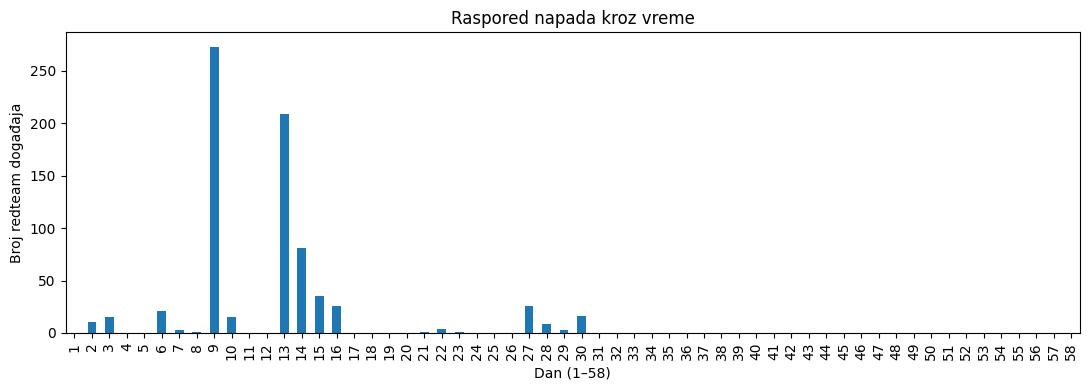

In [ ]:
# --- 5. Vizuelizacija rasporeda napada kroz vreme ---


RESULTS = Path(__file__).resolve().parent.parent / "results"
RESULTS.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 4))
by_day.reindex(range(1, 59), fill_value=0).plot(kind="bar", ax=ax)
ax.set_xlabel("Dan (1–58)")
ax.set_ylabel("Broj redteam događaja")
ax.set_title("Raspored napada kroz vreme")
plt.tight_layout()
plt.savefig(RESULTS / "redteam_by_day.png", dpi=120)
print("Grafik sačuvan u results/redteam_by_day.png")

In [ ]:
# --- 6. Čuvanje liste entiteta  ---
PROC = Path(__file__).resolve().parent.parent / "data" / "processed"
PROC.mkdir(parents=True, exist_ok=True)

pd.Series(users, name="user").to_csv(PROC / "redteam_users.csv", index=False)
pd.Series(all_comps, name="computer").to_csv(
    PROC / "redteam_computers.csv", index=False
)
print("Sačuvano: data/processed/redteam_users.csv i redteam_computers.csv")

Sačuvano: data/processed/redteam_users.csv i redteam_computers.csv
